In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp, Operator
from qiskit.circuit.library import n_local
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

# Transverse Field Ising Model

For a 1D chain of N spins,

$$
H = - J \sum_{i = 0}^{N - 1} Z_i Z_{i+1} - h \sum_{i = 0}^{N-1} X_i,
$$

where we assume periodic boundary conditions, i.e., $Z_N = Z_0$.

In [2]:
# Define the Hamiltonian of the system

def H(N_qubits, J = 1, h = 0.1):
    pauli_str = []
    pauli_coef = []

    for i in range(N_qubits):
        z_str = ['I'] * N_qubits
        z_str[i] = 'Z'
        if i + 1 == N_qubits:  # taking periodic boundary conditions
            z_str[0] = 'Z'
        else:
            z_str[i+1] = 'Z'

        pauli_str.append(''.join(z_str))
        pauli_coef.append(- J)

    for j in range(N_qubits):
        x_str = ['I'] * N_qubits
        x_str[j] = 'X'

        pauli_str.append(''.join(x_str))
        pauli_coef.append(- h)

    return SparsePauliOp(pauli_str, pauli_coef)
        

In [3]:
def build_circuit(N_qubits, reps):
    qc = n_local(N_qubits, rotation_blocks='ry', entanglement_blocks='cz', reps = reps, entanglement='linear')
    return qc.decompose()

def compute_expectation(params, circuit, hamiltonian, backend = None, shots = 4096):

    if backend is None:
        backend = AerSimulator()

    bound = circuit.assign_parameters(params)
    N_qubits = circuit.num_qubits

    pauli_labels = [p.to_label() for p in hamiltonian.paulis]
    meas_circuits = []

    for label in pauli_labels:
        mc = bound.copy()

        for i,p in enumerate(label):
            q = N_qubits - 1 - i
            if p == 'X':
                mc.h(q)
            elif p == 'Y':
                mc.sdg(q)
                mc.h(q)
        mc.measure_all()
        meas_circuits.append(mc)


    tqc = transpile(meas_circuits, backend)
    result = backend.run(tqc, shots=shots).result()

    energy = 0.0
    for i, (label, coef) in enumerate(zip(pauli_labels, hamiltonian.coeffs)):
        counts = result.get_counts(i)
        energy_term = 0.0
        for bitstring, n in counts.items():
            eig = 1
            for i, p in enumerate(label):
                if p != 'I':
                    eig *= 1 - 2 * int(bitstring[i])
            
            energy_term += eig * n
        energy += np.real(coef) * energy_term / shots

    return energy


In [4]:
def vqe_algorithm(N_qubits, J=1, h=0.1, reps=3, shots=4096, method='COBYLA', maxiter=200):
    hamiltonian = H(N_qubits, J, h)
    circuit = build_circuit(N_qubits, reps)
    x0 = np.random.uniform(0, 2*np.pi, circuit.num_parameters)

    history = []
    def cost(theta_params):
        e = compute_expectation(theta_params, circuit, hamiltonian, shots=shots)
        history.append(e)
        return e

    result = minimize(cost, x0, method=method, options = {'maxiter': maxiter})
    return result, np.array(history), circuit

In [5]:
def exact_solution(N_qubits, J = 1, h = 0.1):
    hamiltoninan = H(N_qubits, J, h)
    H_matrix = Operator(hamiltoninan).data
    eigvals = np.linalg.eigvalsh(H_matrix)
    return np.min(eigvals)

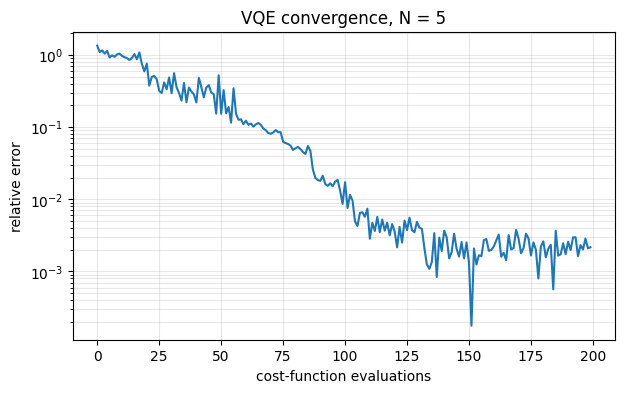

In [6]:

def relative_error(theo, exp):
    return np.abs(theo - exp) / np.abs(theo)

N = 5
result, history, circuit = vqe_algorithm(N, shots = 4096*2, maxiter = 200)
theta_opt = result.x

E_exact = exact_solution(N)
error = relative_error(E_exact, np.array(history))

# Plot convergence of the VQE
plt.figure(figsize=(7,4))
plt.semilogy(error)
plt.xlabel('cost-function evaluations')
plt.ylabel('relative error')
plt.title(f'VQE convergence, N = {N}')
plt.grid(True, which='both', alpha=0.3)
plt.show()